In [ ]:
import pandas as pd

In [ ]:
csv_file_path = "es_data.csv"

df = pd.read_csv(csv_file_path)
df.head()

,id,course_of_study,full_bio,full_image_url,industries,name,organisation,role,school,thumbnail_image_url,wave_id,last_modified_time
0,reclM5g8XAgk138Q1,Mechanical Engineering,"Chinmay Gavankar is Director, Data and Artific...",https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Chinmay Gavankar,Microsoft Corporation,Director-Data & AI,VJTI University of Mumbai,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:01:44.000Z
1,recuMGexISFZy6MkF,"Master of Business Administration, B.Eng in Me...",Denis Koh is the Professional Service Director...,https://advisorysg-mentorship.s3.ap-southeast-...,['Information and Communications Technology' '...,Denis Koh,"Aptos Software Singapore,",Professional Service Director,"University of Technology, Syndey, Nanyang Tech...",https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z
2,rec7OJSBJ8rCSqJRI,Banking and Finance,Yee Choon Yin is a Senior Associate within the...,https://advisorysg-mentorship.s3.ap-southeast-...,['Banking and Finance'],Choon Yin Yee,DBS,senior associate,Singapore Institute of Management - University...,https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T15:36:41.000Z
3,recP44ctWCcSvn1Qr,Bachelor of Accountancy,"In his capacity as a Compliance Testing, Vice ...",https://advisorysg-mentorship.s3.ap-southeast-...,['Banking and Finance'],Derek Chee,Citibank,"Compliance Testing, Vice President",Nanyang Technological University,https://advisorysg-mentorship.s3.ap-southeast-...,2021-2,2023-04-01T01:25:57.000Z
4,rec5gZPt1aMIwwmtG,"Master of Business Administration, Masters of ...",Christian Xia is a consultant at Boston Consul...,https://advisorysg-mentorship.s3.ap-southeast-...,['Consultancy' 'Climate Change & Sustainabilit...,Christian Xia,Boston Consulting Group,Consultant,"INSEAD, National University of Singapore, Nany...",https://advisorysg-mentorship.s3.ap-southeast-...,2023,2023-07-24T14:55:04.000Z


In [ ]:
df = df[['full_bio', 'industries', 'organisation']]
df.head()

,full_bio,industries,organisation
0,"Chinmay Gavankar is Director, Data and Artific...",['Information and Communications Technology' '...,Microsoft Corporation
1,Denis Koh is the Professional Service Director...,['Information and Communications Technology' '...,"Aptos Software Singapore,"
2,Yee Choon Yin is a Senior Associate within the...,['Banking and Finance'],DBS
3,"In his capacity as a Compliance Testing, Vice ...",['Banking and Finance'],Citibank
4,Christian Xia is a consultant at Boston Consul...,['Consultancy' 'Climate Change & Sustainabilit...,Boston Consulting Group


In [ ]:
# randomly chosen description
RANDOM_IDX = 42
random_row = df.iloc[RANDOM_IDX]

full_bio_text = random_row['full_bio']
full_bio_text

'Effendy Ibrahim is currently the Vice President of APJ Marketing at Alteryx, a NYSE-listed software company specialising in the field of analytics automation. In this role, he leads a team of 15 across the Asia Pacific and Japan geography, leading all marketing programs and execution. Prior to this, Effendy has also served in the same capacity in software companies like Google Cloud, Veeam and Symantec. Effendy graduated from Nanyang Technological University with a Bachelor of Business and also holds a MBA from the University of Manchester.'

# 1. TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True, ngram_range=(1, 2))

In [ ]:
def calculate_tfidf(text, vectorizer):
    """
    Calculates TF-IDF scores for the given text using a provided TfidfVectorizer.

    Args:
        text (str): The input text.
        vectorizer (TfidfVectorizer):  Pre-initialized TfidfVectorizer

    Returns:
        list: A list of (word/n-gram, TF-IDF score) pairs, sorted by score in descending order.
    """

    # Fit and transform the text
    tfidf_matrix = vectorizer.fit_transform([text])

    # Get feature names (words/n-grams)
    feature_names = vectorizer.get_feature_names_out()

    # Get TF-IDF scores for the document
    tfidf_scores = tfidf_matrix.toarray()[0]

    # Combine words and scores
    word_score_pairs = list(zip(feature_names, tfidf_scores))

    # Sort by score, descending
    word_score_pairs.sort(key=lambda x: x[1], reverse=True)
    return word_score_pairs

In [ ]:
import time

In [ ]:
start_time = time.time()

# Calculate TF-IDF scores using the function
tfidf_results = calculate_tfidf(full_bio_text, vectorizer)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

# Print the results
print("\nTF-IDF Results:")
if tfidf_results:
    for word, score in tfidf_results:
        print(f"{word}: {score:.4f}")

Calculation took 0.0065 seconds.

TF-IDF Results:
effendy: 0.2847
marketing: 0.1898
software: 0.1898
university: 0.1898
15: 0.0949
15 asia: 0.0949
alteryx: 0.0949
alteryx nyse: 0.0949
analytics: 0.0949
analytics automation: 0.0949
apj: 0.0949
apj marketing: 0.0949
asia: 0.0949
asia pacific: 0.0949
automation: 0.0949
automation role: 0.0949
bachelor: 0.0949
bachelor business: 0.0949
business: 0.0949
business holds: 0.0949
capacity: 0.0949
capacity software: 0.0949
cloud: 0.0949
cloud veeam: 0.0949
companies: 0.0949
companies like: 0.0949
company: 0.0949
company specialising: 0.0949
currently: 0.0949
currently vice: 0.0949
effendy graduated: 0.0949
effendy ibrahim: 0.0949
effendy served: 0.0949
execution: 0.0949
execution prior: 0.0949
field: 0.0949
field analytics: 0.0949
geography: 0.0949
geography leading: 0.0949
google: 0.0949
google cloud: 0.0949
graduated: 0.0949
graduated nanyang: 0.0949
holds: 0.0949
holds mba: 0.0949
ibrahim: 0.0949
ibrahim currently: 0.0949
japan: 0.0949
japan 

In [ ]:
# Extract words from TF-IDF results
tfidf_words = [word for word, score in tfidf_results]

print("\nTF-IDF Words:")
print(tfidf_words)

print("\nTF-IDF Words String Form:")
print(', '.join(tfidf_words))


TF-IDF Words:
['effendy', 'marketing', 'software', 'university', '15', '15 asia', 'alteryx', 'alteryx nyse', 'analytics', 'analytics automation', 'apj', 'apj marketing', 'asia', 'asia pacific', 'automation', 'automation role', 'bachelor', 'bachelor business', 'business', 'business holds', 'capacity', 'capacity software', 'cloud', 'cloud veeam', 'companies', 'companies like', 'company', 'company specialising', 'currently', 'currently vice', 'effendy graduated', 'effendy ibrahim', 'effendy served', 'execution', 'execution prior', 'field', 'field analytics', 'geography', 'geography leading', 'google', 'google cloud', 'graduated', 'graduated nanyang', 'holds', 'holds mba', 'ibrahim', 'ibrahim currently', 'japan', 'japan geography', 'leading', 'leading marketing', 'leads', 'leads team', 'like', 'like google', 'listed', 'listed software', 'manchester', 'marketing alteryx', 'marketing programs', 'mba', 'mba university', 'nanyang', 'nanyang technological', 'nyse', 'nyse listed', 'pacific', 'p

In [ ]:
import matplotlib.pyplot as plt

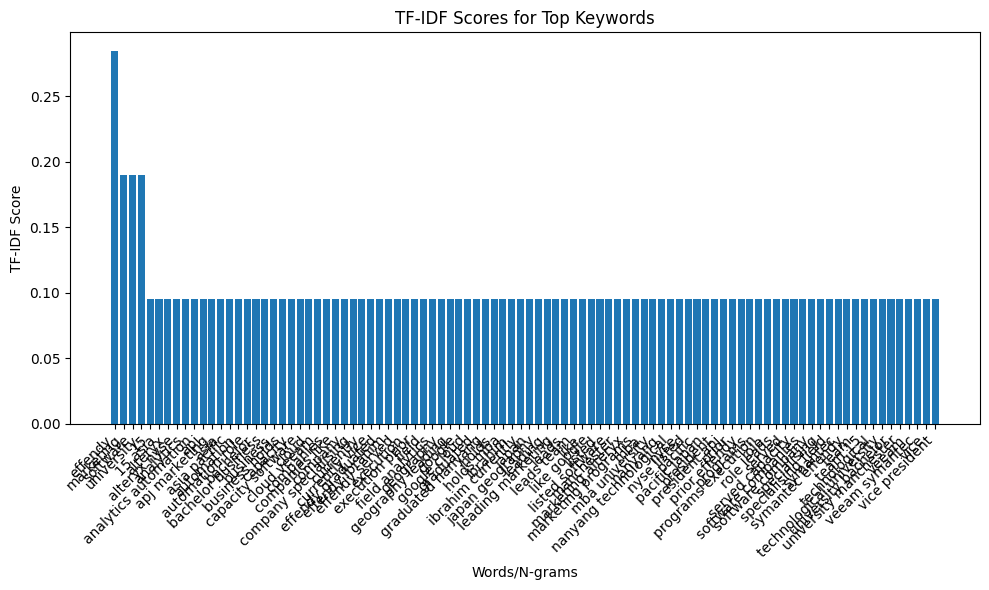

In [ ]:
# Prepare data for plotting
words, scores = zip(*tfidf_results)

# Create bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(words, scores)
plt.xlabel("Words/N-grams")
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF Scores for Top Keywords")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

Visualisation

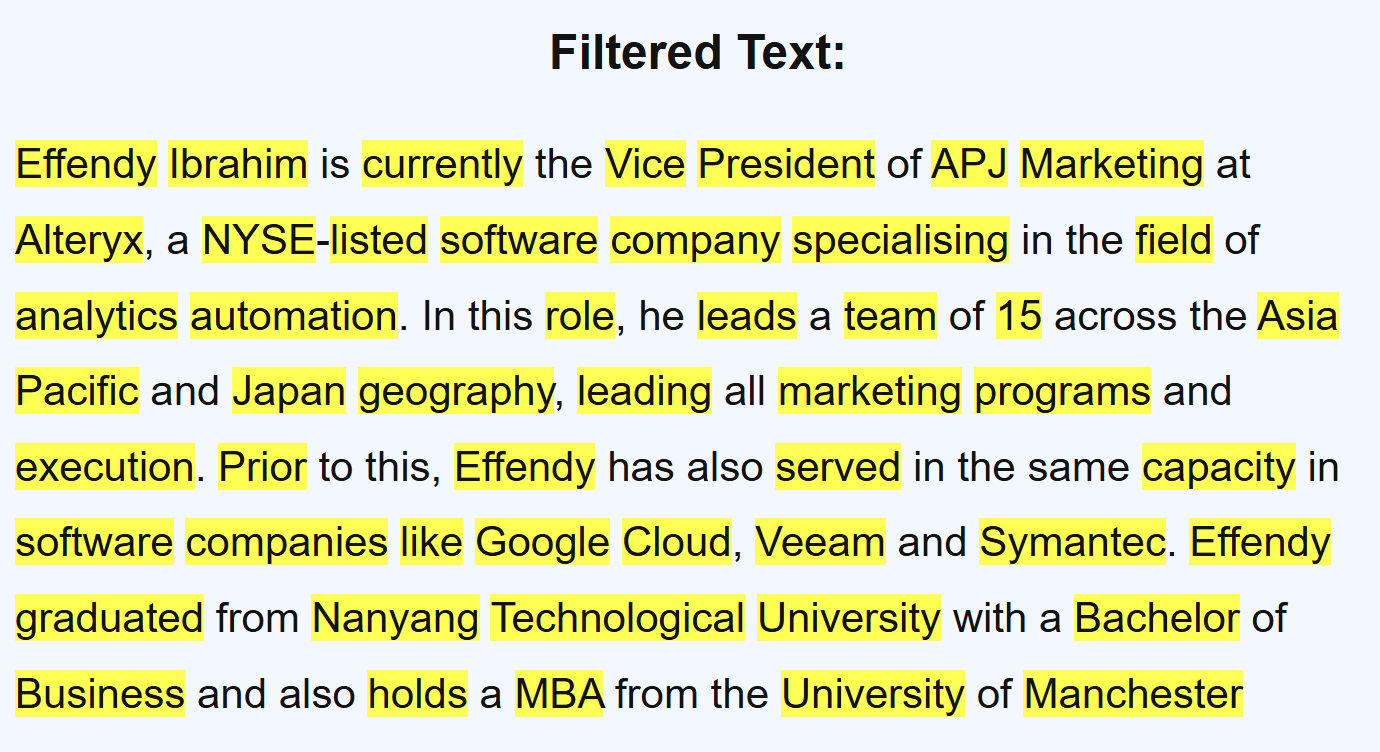

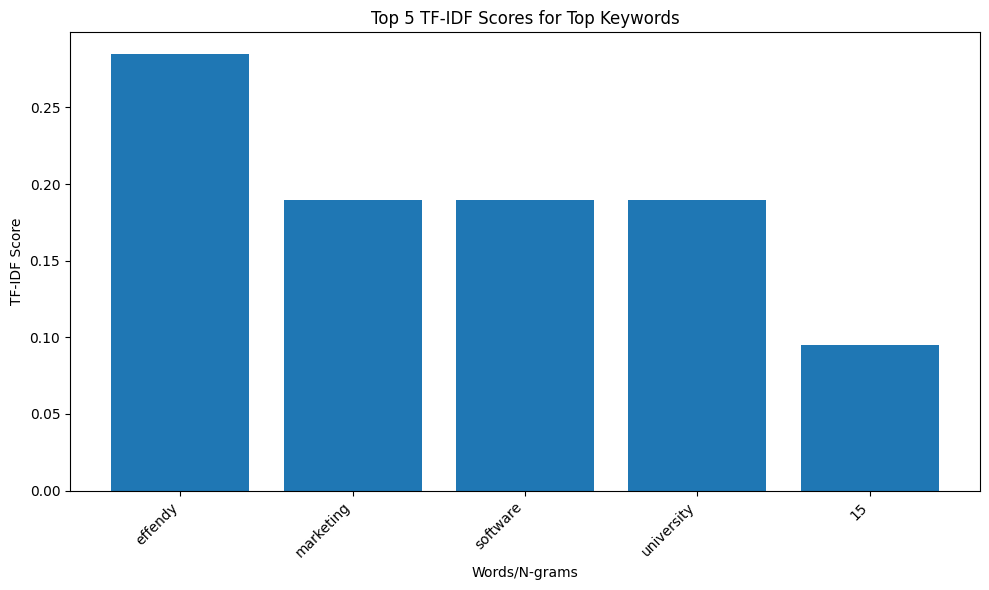

In [ ]:
top_k = 5  # Change this value to show the top K words
words, scores = zip(*tfidf_results[:top_k])

# Create bar chart
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(words, scores)
plt.xlabel("Words/N-grams")
plt.ylabel("TF-IDF Score")
plt.title(f"Top {top_k} TF-IDF Scores for Top Keywords")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
# Extract words from TF-IDF results
tfidf_words_topk = [word for word, score in tfidf_results][:top_k]

print("\nTF-IDF Words:")
print(tfidf_words_topk)

print("\nTF-IDF Words String Form:")
print(', '.join(tfidf_words_topk))


TF-IDF Words:
['effendy', 'marketing', 'software', 'university', '15']

TF-IDF Words String Form:
effendy, marketing, software, university, 15


Visualisation (Top 5)

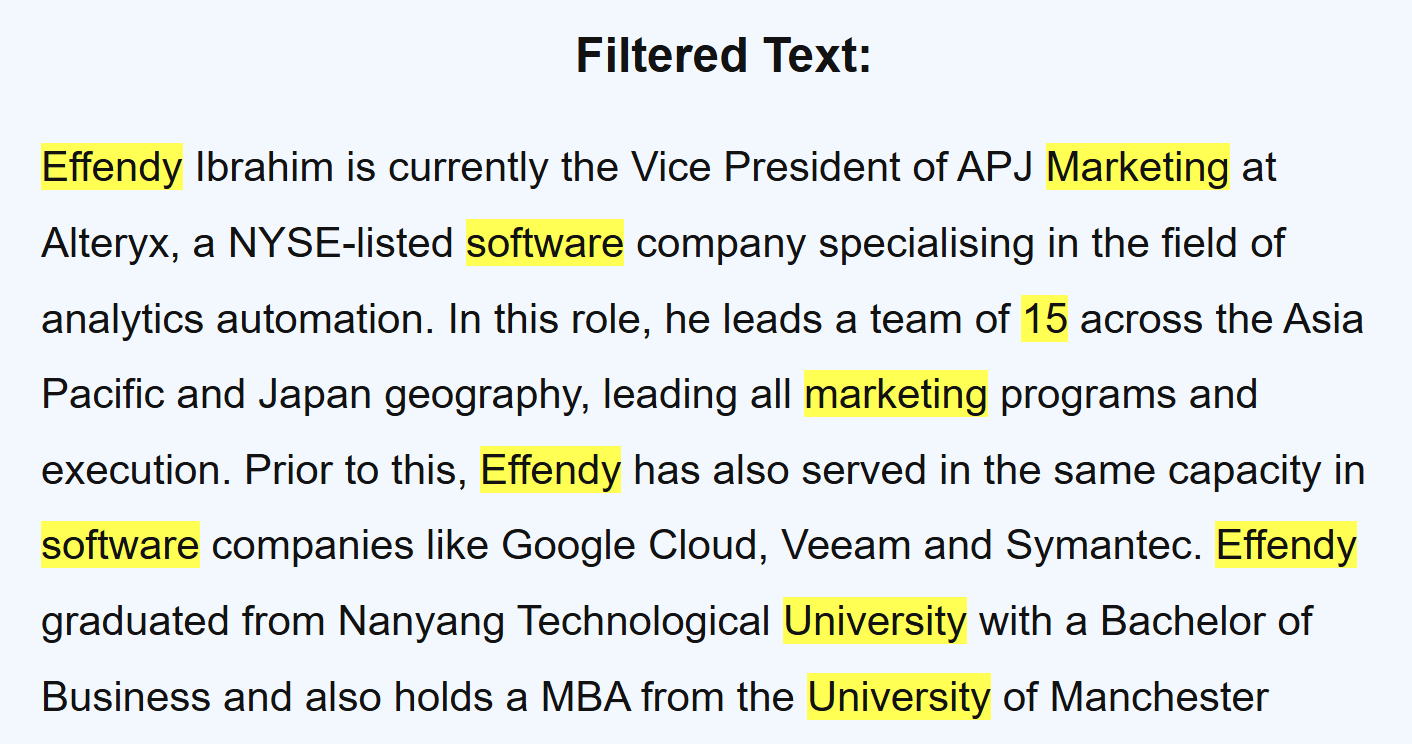

# 2. Revisit SpaCy

In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 71.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
def extract_keywords_spacy(text, model):
    """
    Extracts keywords (entities and noun phrases) from the given text using spaCy.

    Args:
        text (str): The input text.
        model:  The spaCy language model.

    Returns:
        dict: A dictionary containing extracted entities and noun phrases.
    """
    doc = model(text)

    entities = [ent.text for ent in doc.ents]

    # Extract noun phrases, filtering out pronouns
    noun_phrases = [chunk.text for chunk in doc.noun_chunks if chunk.root.pos_ != "PRON"]

    return {
        "entities": entities,
        "noun_phrases": noun_phrases
    }

In [ ]:
start_time = time.time()

keywords = extract_keywords_spacy(full_bio_text, nlp)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Extracted Keywords from Career Experience:")
print(f"Entities: {keywords['entities']}")
print(f"Noun Phrases: {keywords['noun_phrases']}")

Calculation took 0.0357 seconds.
Extracted Keywords from Career Experience:
Entities: ['Effendy Ibrahim', 'APJ Marketing at Alteryx', 'NYSE', '15', 'the Asia Pacific', 'Japan', 'Effendy', 'Google Cloud', 'Symantec', 'Effendy', 'Nanyang Technological University', 'a Bachelor of Business', 'the University of Manchester']
Noun Phrases: ['Effendy Ibrahim', 'the Vice President', 'APJ Marketing', 'Alteryx', 'a NYSE-listed software company', 'the field', 'analytics automation', 'this role', 'a team', 'the Asia Pacific and Japan geography', 'all marketing programs', 'execution', 'Effendy', 'the same capacity', 'software companies', 'Google Cloud', 'Veeam', 'Effendy', 'Nanyang Technological University', 'a Bachelor', 'Business', 'a MBA', 'the University', 'Manchester']


In [ ]:
# Extract words from SpaCy keywords (entities)
spacy_words_entities = [word for word in keywords['entities']]

print("\nSpaCy Words (Entities):")
print(spacy_words_entities)

print("\nSpaCy Words (Entities) String Form:")
print(', '.join(spacy_words_entities))


SpaCy Words (Entities):
['Effendy Ibrahim', 'APJ Marketing at Alteryx', 'NYSE', '15', 'the Asia Pacific', 'Japan', 'Effendy', 'Google Cloud', 'Symantec', 'Effendy', 'Nanyang Technological University', 'a Bachelor of Business', 'the University of Manchester']

SpaCy Words (Entities) String Form:
Effendy Ibrahim, APJ Marketing at Alteryx, NYSE, 15, the Asia Pacific, Japan, Effendy, Google Cloud, Symantec, Effendy, Nanyang Technological University, a Bachelor of Business, the University of Manchester


Visualisation

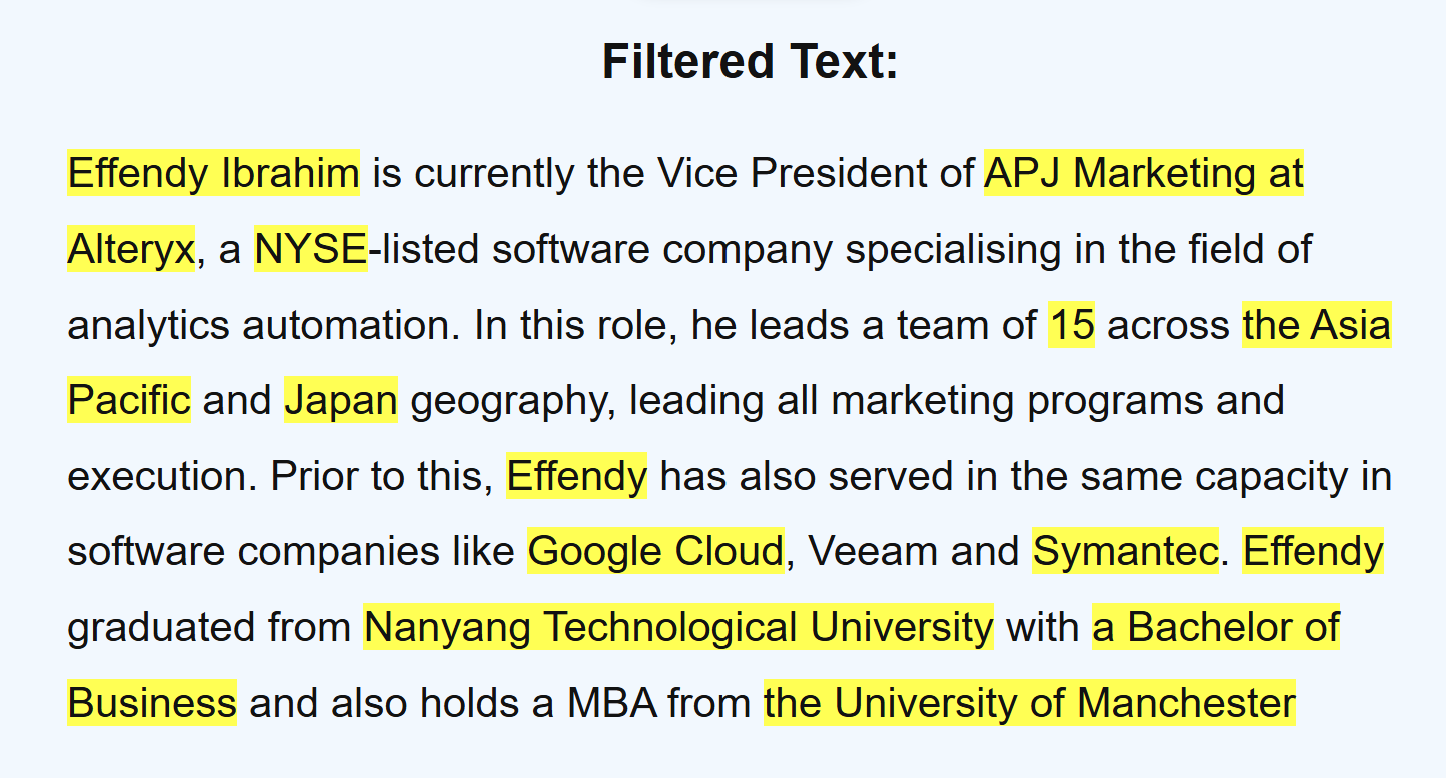

In [ ]:
# Extract words from SpaCy keywords (nouns)
spacy_words_nouns = [word for word in keywords['noun_phrases']]

print("\nSpaCy Words (Nouns):")
print(spacy_words_nouns)

print("\nSpaCy Words (Nouns) String Form:")
print(', '.join(spacy_words_nouns))


SpaCy Words (Nouns):
['Effendy Ibrahim', 'the Vice President', 'APJ Marketing', 'Alteryx', 'a NYSE-listed software company', 'the field', 'analytics automation', 'this role', 'a team', 'the Asia Pacific and Japan geography', 'all marketing programs', 'execution', 'Effendy', 'the same capacity', 'software companies', 'Google Cloud', 'Veeam', 'Effendy', 'Nanyang Technological University', 'a Bachelor', 'Business', 'a MBA', 'the University', 'Manchester']

SpaCy Words (Nouns) String Form:
Effendy Ibrahim, the Vice President, APJ Marketing, Alteryx, a NYSE-listed software company, the field, analytics automation, this role, a team, the Asia Pacific and Japan geography, all marketing programs, execution, Effendy, the same capacity, software companies, Google Cloud, Veeam, Effendy, Nanyang Technological University, a Bachelor, Business, a MBA, the University, Manchester


Visualisation

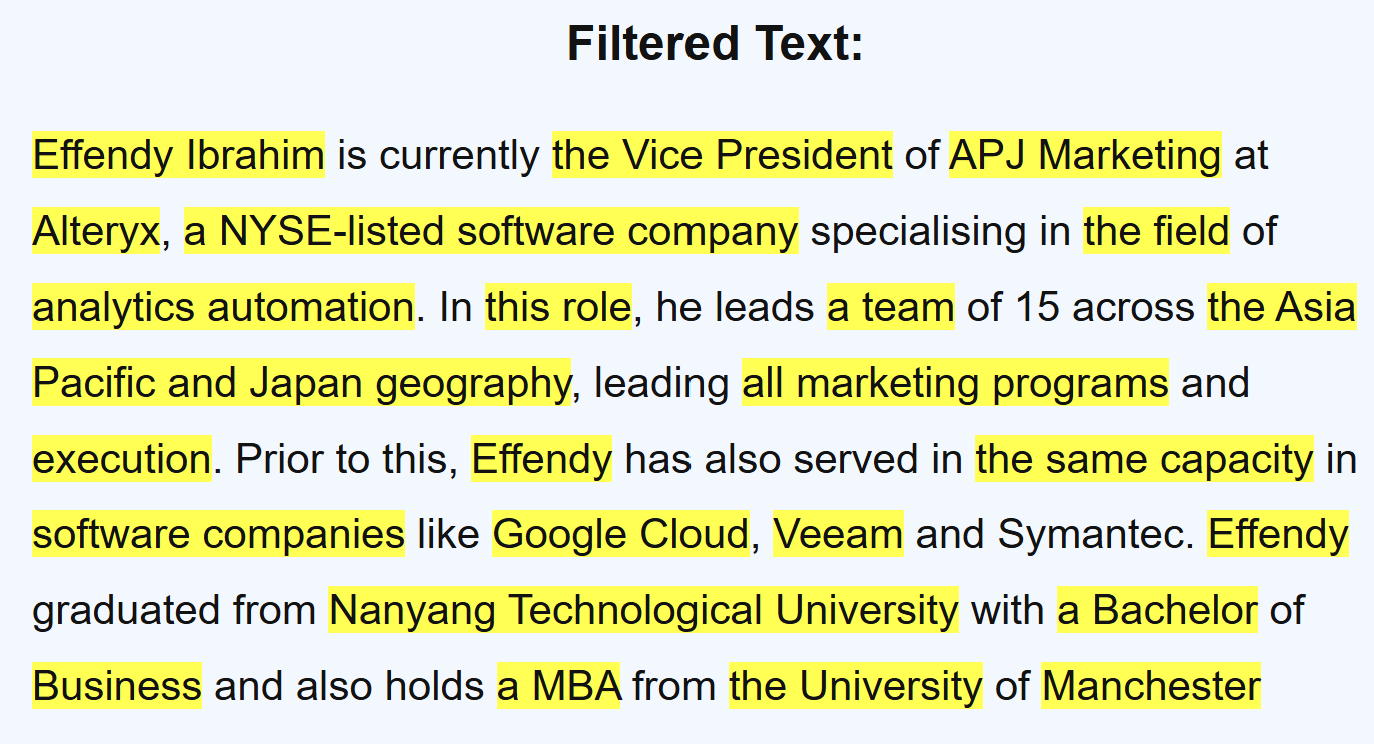

# 3. Exploring HF Transformers

In [ ]:
!pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
from transformers import pipeline

Documentation


BERT Base:

https://huggingface.co/dslim/bert-base-NER


Finetuned NERT:

https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english

https://www.promptlayer.com/models/bert-large-cased-finetuned-conll03-english

In [ ]:
BERT_BASE = "dslim/bert-base-NER"
BERT_LARGE = "dbmdz/bert-large-cased-finetuned-conll03-english"

def extract_ner_huggingface(text, model_name):
    """
    Extracts named entities from the given text using a specified Hugging Face Transformer model.

    Args:
        text (str): The input text.
        model_name (str, optional): The name of the Hugging Face Transformer model to use.

    Returns:
        list: A list of dictionaries, where each dictionary represents a named entity and
            contains keys like 'entity', 'score', 'start', 'end', and 'word'.
    """
    # Create a NER pipeline with the specified model
    ner_pipeline = pipeline("ner", model=model_name, aggregation_strategy="simple")

    # Apply the pipeline to the text
    ner_results = ner_pipeline(text)
    return ner_results

In [ ]:
start_time = time.time()

ner_results_base = extract_ner_huggingface(full_bio_text, BERT_BASE)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("Results from dslim/bert-base-NER:")
for result in ner_results_base:
    print(result)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Calculation took 13.8201 seconds.
Results from dslim/bert-base-NER:
{'entity_group': 'PER', 'score': np.float32(0.9995721), 'word': 'E', 'start': 0, 'end': 1}
{'entity_group': 'PER', 'score': np.float32(0.99508685), 'word': '##ffe', 'start': 1, 'end': 4}
{'entity_group': 'PER', 'score': np.float32(0.77243394), 'word': '##ndy Ibrahim', 'start': 4, 'end': 15}
{'entity_group': 'ORG', 'score': np.float32(0.96622753), 'word': 'APJ Marketing', 'start': 51, 'end': 64}
{'entity_group': 'ORG', 'score': np.float32(0.9986345), 'word': 'Alteryx', 'start': 68, 'end': 75}
{'entity_group': 'MISC', 'score': np.float32(0.9648956), 'word': 'NYSE', 'start': 79, 'end': 83}
{'entity_group': 'LOC', 'score': np.float32(0.9983735), 'word': 'Asia Pacific', 'start': 206, 'end': 218}
{'entity_group': 'LOC', 'score': np.float32(0.9996772), 'word': 'Japan', 'start': 223, 'end': 228}
{'entity_group': 'PER', 'score': np.float32(0.9990747), 'word': 'E', 'start': 301, 'end': 302}
{'entity_group': 'PER', 'score': np.fl

In [ ]:
# Example usage with dbmdz/bert-large-cased-finetuned-conll03-english

start_time = time.time()

ner_results_large = extract_ner_huggingface(full_bio_text, BERT_LARGE)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

print("\nResults from dbmdz/bert-large-cased-finetuned-conll03-english:")
for result in ner_results_large:
  print(result)

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Device set to use cpu


Calculation took 22.7547 seconds.

Results from dbmdz/bert-large-cased-finetuned-conll03-english:
{'entity_group': 'PER', 'score': np.float32(0.9994378), 'word': 'Effendy Ibrahim', 'start': 0, 'end': 15}
{'entity_group': 'ORG', 'score': np.float32(0.8186906), 'word': 'APJ Marketing', 'start': 51, 'end': 64}
{'entity_group': 'ORG', 'score': np.float32(0.99874735), 'word': 'Alteryx', 'start': 68, 'end': 75}
{'entity_group': 'MISC', 'score': np.float32(0.93139076), 'word': 'NYSE', 'start': 79, 'end': 83}
{'entity_group': 'LOC', 'score': np.float32(0.9936557), 'word': 'Asia Pacific', 'start': 206, 'end': 218}
{'entity_group': 'LOC', 'score': np.float32(0.99973184), 'word': 'Japan', 'start': 223, 'end': 228}
{'entity_group': 'PER', 'score': np.float32(0.99881595), 'word': 'Effendy', 'start': 301, 'end': 308}
{'entity_group': 'ORG', 'score': np.float32(0.99429226), 'word': 'Google Cloud', 'start': 373, 'end': 385}
{'entity_group': 'ORG', 'score': np.float32(0.9815343), 'word': 'Veeam', 'star

In [ ]:
words_large = [result['word'] for result in ner_results_large]

print("\nWords :")
print(words_large)

print("\nWords String Form:")
print(', '.join(words_large))


Words :
['Effendy Ibrahim', 'APJ Marketing', 'Alteryx', 'NYSE', 'Asia Pacific', 'Japan', 'Effendy', 'Google Cloud', 'Veeam', 'Symantec', 'Effendy', 'Nanyang Technological University', 'University of Manchester']

Words String Form:
Effendy Ibrahim, APJ Marketing, Alteryx, NYSE, Asia Pacific, Japan, Effendy, Google Cloud, Veeam, Symantec, Effendy, Nanyang Technological University, University of Manchester


Visualisation

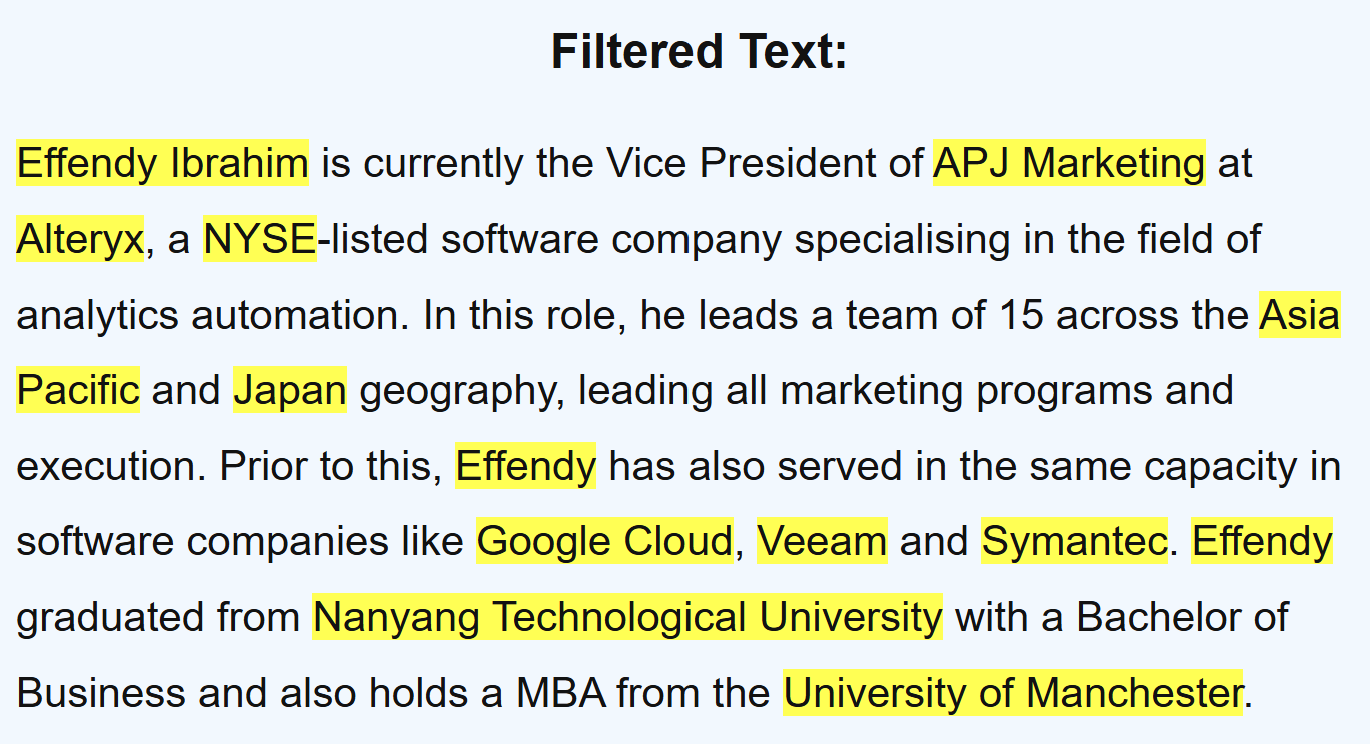

# 4. Exploring Stanford Core NLP

In [ ]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 37.9 MB/s eta 0:00:00


In [ ]:
import stanza

In [ ]:
# Initialize the pipeline
nlp_model = stanza.Pipeline('en', processors='tokenize,ner')

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json


INFO:stanza:Loading these models for language: en (English):
| Processor | Package                   |
-----------------------------------------
| tokenize  | combined                  |
| mwt       | combined                  |
| ner       | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


In [ ]:
def process_text_with_stanza_ner(text, nlp_model):
    """
    Processes the given text using the provided StanfordNLP model to extract
    named entities and tokens with their NER tags.

    Args:
        text (str): The text to process.
        nlp_model (Pipeline): A pre-initialized StanfordNLP Pipeline object.

    Returns:
        dict: A dictionary containing the extracted information with two keys:
            - 'named_entities': A list of dictionaries, where each dictionary
              represents a named entity and has 'text' and 'type' keys.
            - 'tokens_with_ner_tags': A list of dictionaries, where each dictionary
              represents a token and has 'token' and 'ner_tag' keys.
              Returns empty lists if no entities or tokens are found.
    """
    doc = nlp_model(text)  # Process the text

    named_entities = []
    for ent in doc.ents:
        named_entities.append({
            'text': ent.text,
            'type': ent.type
        })

    tokens_with_ner_tags = []
    for sentence in doc.sentences:
        for token in sentence.tokens:
            tokens_with_ner_tags.append({
                'token': token.text,
                'ner_tag': token.ner  # Stanza uses .ner for NER tag
            })

    return {
        'named_entities': named_entities,
        'tokens_with_ner_tags': tokens_with_ner_tags
    }

In [ ]:
start_time = time.time()

results = process_text_with_stanza_ner(full_bio_text, nlp_model)

end_time = time.time()
execution_time = end_time - start_time

print(f"Calculation took {execution_time:.4f} seconds.")

# Print Named Entities
print("Named Entities:")
if results['named_entities']:
    for entity in results['named_entities']:
        print(f"Entity: {entity['text']}, Type: {entity['type']}")
else:
    print("No named entities found.")

Calculation took 1.9142 seconds.
Named Entities:
Entity: Effendy Ibrahim, Type: PERSON
Entity: APJ Marketing, Type: ORG
Entity: Alteryx, Type: ORG
Entity: NYSE, Type: ORG
Entity: 15, Type: CARDINAL
Entity: the Asia Pacific, Type: LOC
Entity: Japan, Type: GPE
Entity: Effendy, Type: ORG
Entity: Google Cloud, Type: ORG
Entity: Veeam, Type: ORG
Entity: Symantec, Type: ORG
Entity: Effendy, Type: PERSON
Entity: Nanyang Technological University, Type: ORG
Entity: MBA, Type: WORK_OF_ART
Entity: the University of Manchester, Type: ORG


Visualisation

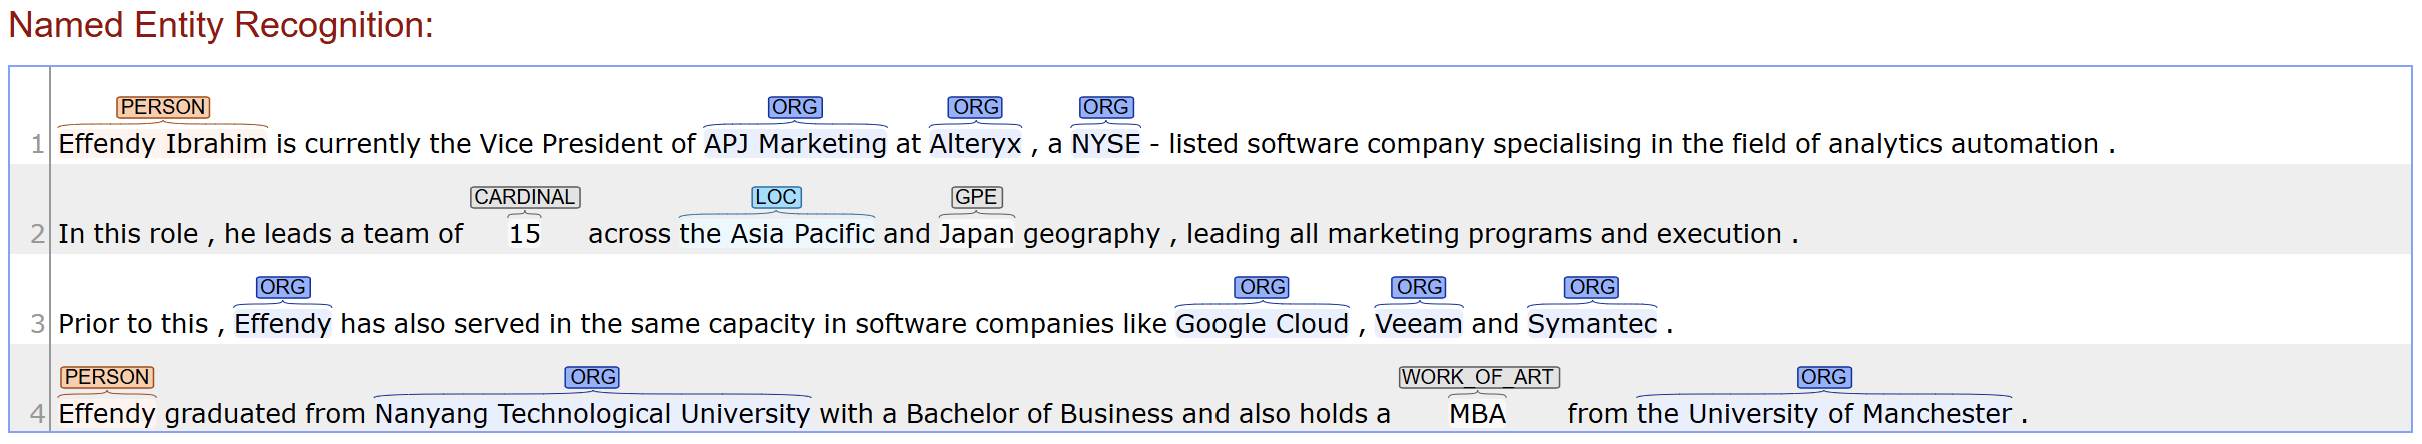